In [1]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import datetime

X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [5]:
model = Sequential([
    Dense(100, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(50, activation='relu'),
    Dense(1)
])

C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=500,
    callbacks=[tensorboard_callback, EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=1
)

Epoch 1/500


 1/59 ━━━━━━━━━━━━━━━━━━━━ 3:18 3s/step - loss: 4691.8374 - mae: 67.9542

 4/59 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4582.9585 - mae: 67.0134

 9/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4551.3711 - mae: 66.7819

15/59 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4520.2524 - mae: 66.5556

...

34/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5853 - mae: 1.3708

42/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5677 - mae: 1.3655

47/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5756 - mae: 1.3658

54/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3.5991 - mae: 1.3680

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.6090 - mae: 1.3686 - val_loss: 6.4792 - val_mae: 1.9106


In [7]:
y_pred = model.predict(X_test_scaled).flatten()

 1/15 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [8]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 6.063364551315903
Mean Absolute Error (MAE): 1.786961895201851
R-squared (R²): 0.9346891641616821


In [9]:
import json

metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\metrics\bigbraintime_metrics.json", "w") as f:
    json.dump(metrics, f)

In [10]:
import pickle

with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime_model.pkl", "wb") as f:
    pickle.dump(model, f)

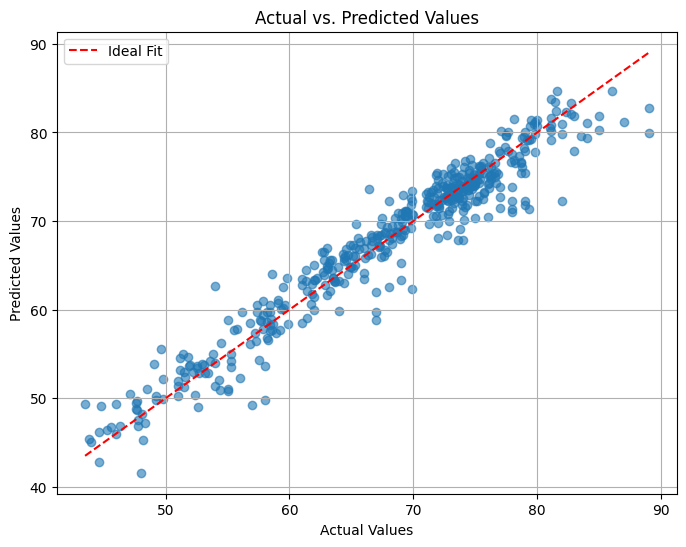

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime\1.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
residuals = y_test.values.flatten() - y_pred.flatten()

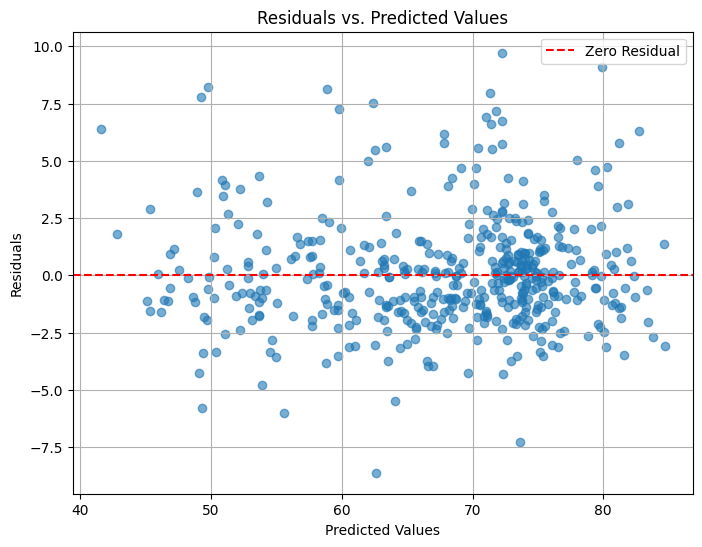

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime\2.png", dpi=300, bbox_inches="tight")
plt.show()

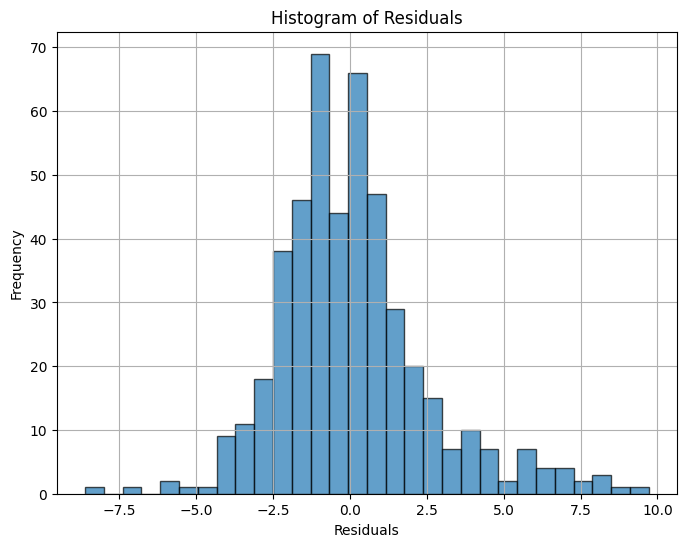

In [14]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\bigbraintime\3.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:

print(f"tensorboard --logdir {log_dir}")

tensorboard --logdir logs/fit/20250123-112504
